# Notebook 1: When the Bond Breaks — An Introduction to Multireference Chemistry

**CSC Spring School on Computational Chemistry 2026**  
**Multireference Quantum Chemistry**

---

## Where we are coming from

In the earlier exercises you used ORCA to optimize molecular structures and calculate vibrational frequencies with DFT. You wrote input files, ran jobs, and interpreted energies and spectra — all near the equilibrium geometry of stable molecules.

If you come from a molecular dynamics or force field background, you are used to thinking about molecules in similar terms: atoms connected by bonds, bonds described by harmonic potentials or Lennard-Jones parameters. The electrons are invisible — they are baked into the parameters.

Both of these pictures — DFT near equilibrium and classical force fields — work extremely well for what they are designed to do. The DFT calculations you did earlier are not wrong. But they share a common assumption: that the electronic structure can be described by **a single dominant configuration of electrons in orbitals**.

This notebook asks: *what happens when that assumption breaks down?*

---

## The simplest possible bond

We will use the hydrogen molecule — two protons, two electrons — as our laboratory. It is the simplest covalent bond that exists, and yet it contains all the essential physics of the multireference problem.

Start by thinking about a single hydrogen atom. It has one proton and one electron. Quantum mechanics tells us the electron does not sit at a fixed position — it occupies a **1s orbital**, a spherical probability cloud around the nucleus.

Now bring two hydrogen atoms together. As the atoms approach each other, their 1s orbitals begin to overlap and interact. Two atomic orbitals combine to form two **molecular orbitals**:

- **σ (bonding)**: the sum of the two 1s orbitals — electron density *between* the nuclei, lower energy
- **σ\* (antibonding)**: the difference — a node between the nuclei, higher energy

At the equilibrium bond length (~0.74 Å), both electrons sit in the σ orbital with opposite spins. This is a **single configuration** — one electron arrangement dominates, and single-reference methods (RHF, DFT) describe this beautifully. This is exactly what your force field's H–H bond parameter encodes.

But now stretch the bond. Pull the atoms apart. At some point, each hydrogen atom *must* recover its own electron. The wavefunction can no longer be described by a single configuration — it needs **two**:

$$\Psi \propto |\sigma\bar{\sigma}\rangle - |\sigma^*\bar{\sigma}^*\rangle$$

Both configurations become equally important at dissociation. This is **static correlation** — and it is the heart of the multireference problem.

---

## Learning objectives

By the end of this notebook you will be able to:

- Visualise the molecular orbitals of H₂ and understand how they arise from atomic orbital interactions
- Explain what a potential energy curve (PEC) is and what *correct* dissociation looks like
- Identify where and why RHF and DFT fail for bond breaking — and why this is not a flaw but a known limitation
- Understand spin contamination in UHF as a symptom of the underlying problem
- Interpret natural orbital (NO) occupation numbers as a diagnostic for multireference character
- Explain qualitatively why CASSCF(2,2) gives the correct dissociation limit

---

## A note on scope

The goal of this notebook is not to show that DFT is unreliable — it is not. DFT and the calculations you did earlier are the right tool for equilibrium chemistry of most molecules. The goal is to understand *where* and *why* a richer description becomes necessary, so that you know when to reach for multireference methods.

---

## Setup

In [1]:
import os
import re
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from IPython.display import Image
from opi.output.grepper.recipes import get_float_from_line

ORCA_HOME     = os.environ.get('ORCA_HOME', '')
ORCA          = f"{ORCA_HOME}/orca"
HARTREE_TO_EV = 27.2114

JOBDIR = Path('h2')
JOBDIR.mkdir(exist_ok=True)

print(f"ORCA: {ORCA}")

ORCA: /home/runeberg/opt/orca_6_1_1_linux_x86-64_shared_openmpi418_avx2/orca


---
## Part 0: Visualising the H₂ molecule

Before running any calculations, let's look at the molecule we're studying. The cell below uses **nglview** to show H₂ at its equilibrium geometry.

After that we visualise the two key molecular orbitals qualitatively:
- The **σ bonding orbital** — electron density concentrated *between* the nuclei
- The **σ\* antibonding orbital** — a node *between* the nuclei, density pushed to the outside

At equilibrium, both electrons occupy the σ orbital. The schematic below illustrates how the wavefunction changes as the bond stretches.

In [2]:
import nglview as nv
from ase import Atoms

# H2 at equilibrium geometry
h2 = Atoms('H2', positions=[[0, 0, 0], [0.74, 0, 0]])

view = nv.show_ase(h2)
view.add_representation('ball+stick')
view.camera = 'orthographic'
view

NGLWidget()

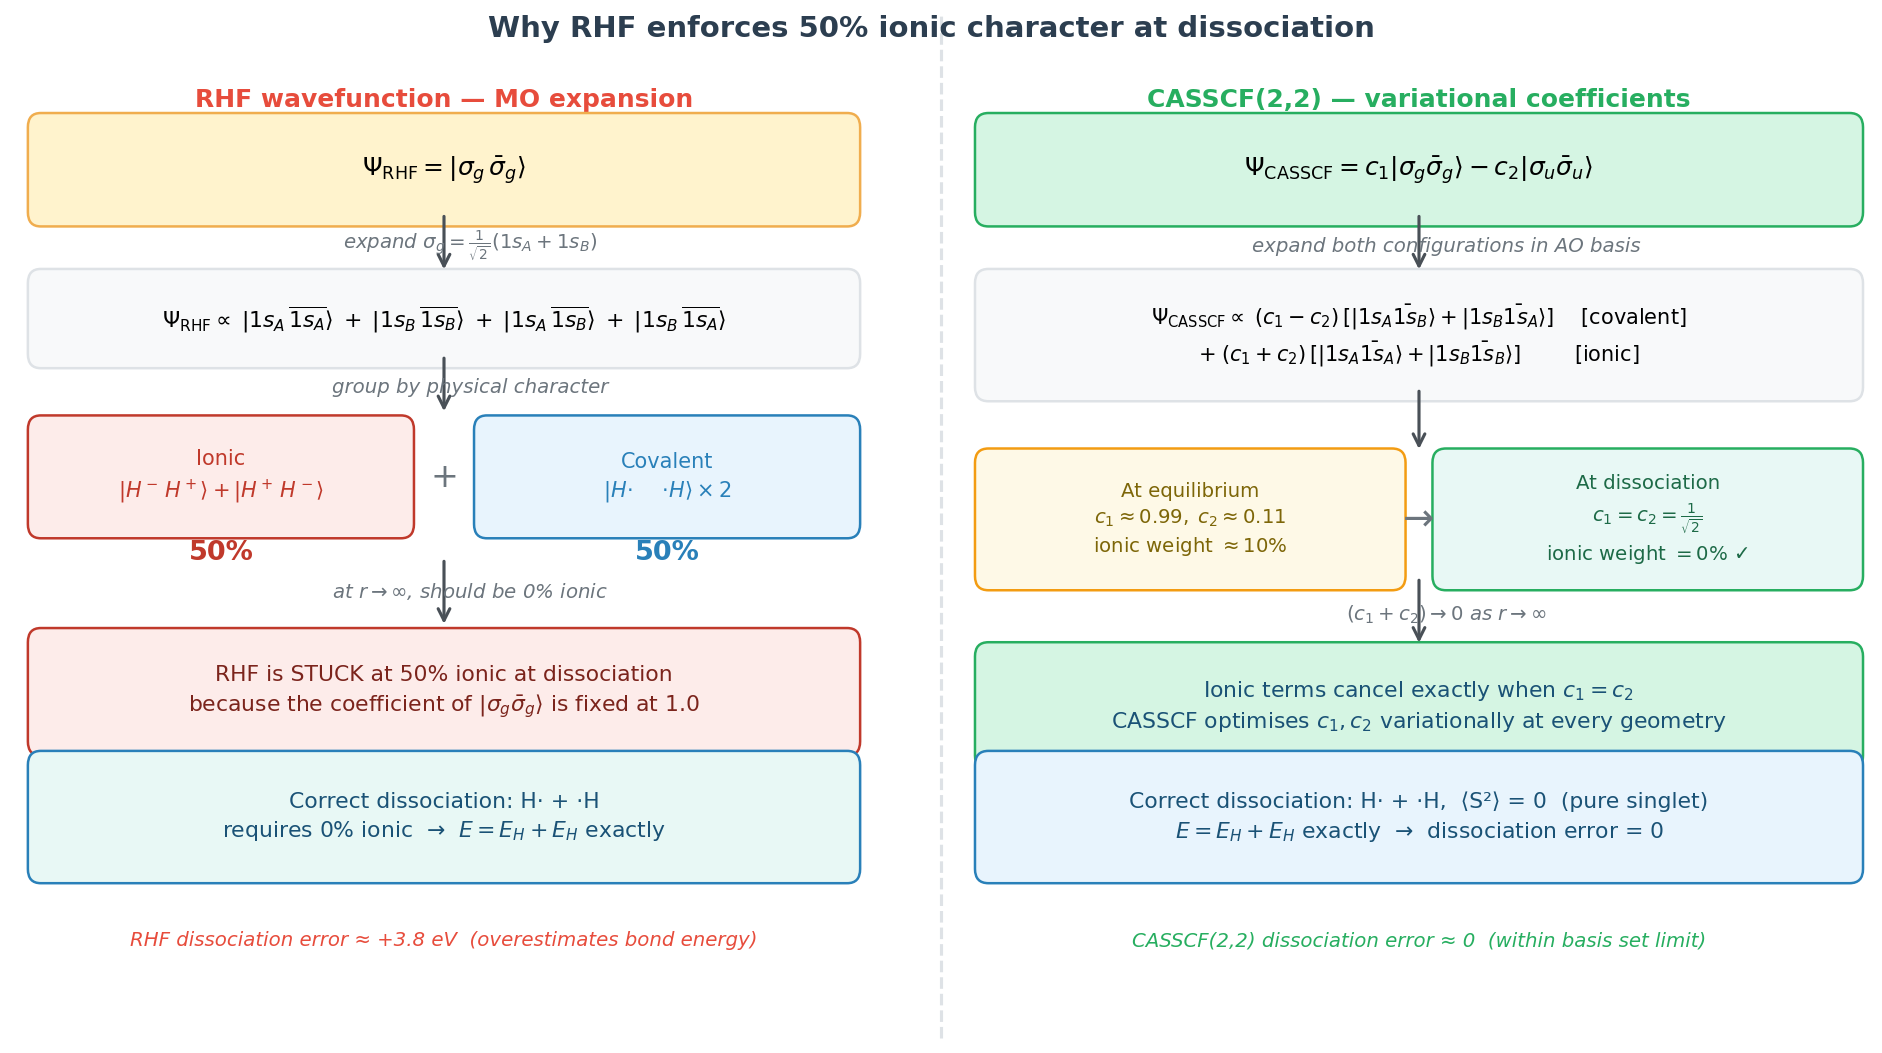

In [3]:
Image('h2_wfn_schematic.png')

---
## Part 1: A single-point RHF calculation at equilibrium

The wavefunction schematic above shows the physical picture. Now let's compute it.

We run one **Restricted Hartree-Fock (RHF)** calculation at the equilibrium geometry (r = 0.74 Å). RHF is the simplest quantum chemical method — both electrons are forced into the same spatial orbital (σ), with opposite spins. This is exactly the single-configuration picture from the introduction.

The key parts of an ORCA input file (familiar from the earlier exercises):
- `!` line: method and basis set
- `%pal nprocs N end`: number of CPU cores
- `* xyz charge multiplicity ... *`: molecular geometry

> **Why def2-SVP?** It is a small but balanced basis set — fast enough for a scan over 16 geometries × 4 methods, and large enough to show the physics clearly.

In [4]:
%%writefile h2/h2_rhf.inp
! RHF def2-SVP TightSCF
%pal nprocs 1 end
* xyz 0 1
H  0.0000  0.0000  0.0000
H  0.7400  0.0000  0.0000
*

Writing h2/h2_rhf.inp


In [5]:
!$ORCA_HOME/orca h2/h2_rhf.inp > h2/h2_rhf.out
!grep "TERMINATED" h2/h2_rhf.out
!grep "FINAL SINGLE POINT ENERGY" h2/h2_rhf.out
!grep "TOTAL RUN TIME" h2/h2_rhf.out

                             ****ORCA TERMINATED NORMALLY****
FINAL SINGLE POINT ENERGY        -1.128893619388
TOTAL RUN TIME: 0 days 0 hours 0 minutes 0 seconds 333 msec


You can open `h2/h2_rhf.out` in the file browser on the left to explore the full ORCA output.

**Q1.** The total RHF energy is around −1.12 Hartree. What does this number represent physically? Why is it negative?

*Your answer:*
```

```

---
## Part 2: Scanning the H₂ potential energy curve

Now we will compute the H₂ energy at a series of H–H distances using four methods:

| Method | Description |
|--------|-------------|
| RHF | Restricted HF — both electrons forced into the same spatial orbital |
| UHF | Unrestricted HF — α and β electrons in separate orbitals |
| B3LYP | Hybrid DFT (restricted) |
| CASSCF(2,2) | 2 electrons in 2 orbitals (σ, σ*) — the minimal multireference method |

All calculations use **def2-SVP**.

> **Broken-symmetry guess:** The UHF calculations use `FlipSpin` to place α spin on one H and β on the other, forcing the SCF to search for the broken-symmetry solution. Without this, UHF converges to the RHF solution near equilibrium and ⟨S²⟩ stays 0 throughout.

> **Note on parallelism:** H₂/def2-SVP is too small for parallel post-SCF modules — `orca_casscf_mpi` aborts when there are fewer basis functions than MPI ranks. All calculations here use `nprocs 1`. For this tiny system serial is actually faster.

The scan runs 16 geometries × 4 methods = 64 jobs. With H₂ serial it should finish in a few minutes.

In [6]:
r_values = np.array([0.6, 0.7, 0.74, 0.8, 0.9, 1.0, 1.1, 1.2,
                     1.4, 1.6, 1.8, 2.0, 2.5, 3.0, 4.0, 5.0])

def run_orca(label, input_text):
    """Write input to JOBDIR, run ORCA, return path to .out file."""
    inp = JOBDIR / f"{label}.inp"
    out = JOBDIR / f"{label}.out"
    inp.write_text(input_text)
    with open(out, 'w') as fh:
        subprocess.run([ORCA, str(inp)],
                       stdout=fh, stderr=subprocess.STDOUT)
    return out

def get_energy(out_file):
    """Return last FINAL SINGLE POINT ENERGY from ORCA output."""
    m = re.findall(r'FINAL SINGLE POINT ENERGY\s+(-?\d+\.\d+)',
                   Path(out_file).read_text())
    return float(m[-1]) if m else float('nan')

energies = {k: [] for k in ['RHF', 'UHF', 'B3LYP', 'CASSCF']}

for r in r_values:
    tag  = f"h2_{r:.2f}".replace('.', 'p')
    geom = f"H  0.0000  0.0000  0.0000\nH  {r:.4f}  0.0000  0.0000"

    energies['RHF'].append(get_energy(run_orca(f"{tag}_rhf", f"""! RHF def2-SVP TightSCF
%pal nprocs 1 end
* xyz 0 1
{geom}
*
""")))

    energies['UHF'].append(get_energy(run_orca(f"{tag}_uhf", f"""! UHF def2-SVP TightSCF
%pal nprocs 1 end
%scf
  Guess Pmodel
  FlipSpin 1
  FinalMs 0.0
end
* xyz 0 1
{geom}
*
""")))

    energies['B3LYP'].append(get_energy(run_orca(f"{tag}_b3lyp", f"""! B3LYP def2-SVP TightSCF
%pal nprocs 1 end
* xyz 0 1
{geom}
*
""")))

    energies['CASSCF'].append(get_energy(run_orca(f"{tag}_casscf", f"""! RHF def2-SVP TightSCF
%pal nprocs 1 end
%casscf
  nel    2
  norb   2
  nroots 1
  printlevel 3
end
* xyz 0 1
{geom}
*
""")))

    print(f"r = {r:.2f} Å  done", flush=True)

for k in energies:
    energies[k] = np.array(energies[k])

print("\n✓ Scan complete.")

r = 0.60 Å  done
r = 0.70 Å  done
r = 0.74 Å  done
r = 0.80 Å  done
r = 0.90 Å  done
r = 1.00 Å  done
r = 1.10 Å  done
r = 1.20 Å  done
r = 1.40 Å  done
r = 1.60 Å  done
r = 1.80 Å  done
r = 2.00 Å  done
r = 2.50 Å  done
r = 3.00 Å  done
r = 4.00 Å  done
r = 5.00 Å  done

✓ Scan complete.


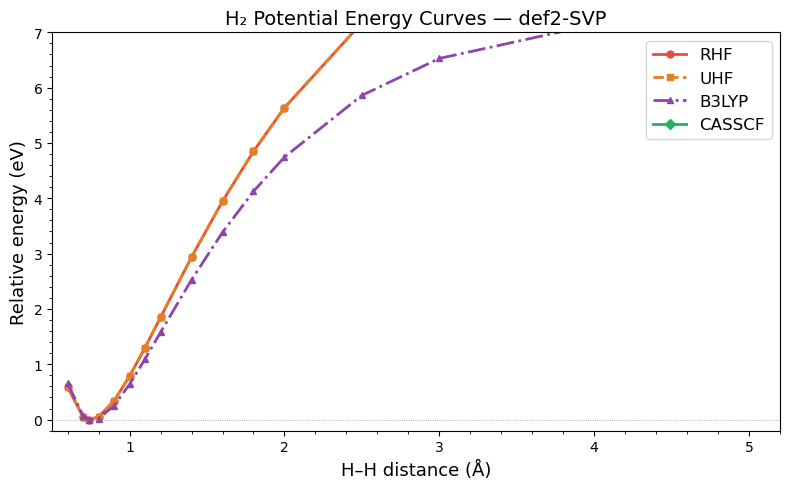

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

colors  = {'RHF': '#e74c3c', 'UHF': '#e67e22', 'B3LYP': '#8e44ad', 'CASSCF': '#27ae60'}
styles  = {'RHF': '-',       'UHF': '--',       'B3LYP': '-.',       'CASSCF': '-'}
markers = {'RHF': 'o',       'UHF': 's',        'B3LYP': '^',        'CASSCF': 'D'}

for method, E in energies.items():
    E_rel = (E - E.min()) * HARTREE_TO_EV
    ax.plot(r_values, E_rel,
            color=colors[method], ls=styles[method],
            marker=markers[method], ms=5, label=method, lw=2)

ax.set_xlabel('H–H distance (Å)', fontsize=13)
ax.set_ylabel('Relative energy (eV)', fontsize=13)
ax.set_title('H₂ Potential Energy Curves — def2-SVP', fontsize=14)
ax.set_xlim(0.5, 5.2)
ax.set_ylim(-0.2, 7.0)
ax.axhline(0, color='grey', lw=0.5, ls=':')
ax.legend(fontsize=12)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
plt.tight_layout()
plt.savefig('h2_pec.pdf')
plt.show()

### ✏️ Questions — Part 2

**Q2.** The experimental dissociation energy of H₂ is 4.52 eV. Which method(s) approach the correct dissociation limit, and which do not?

*Your answer:*
```

```

**Q3.** RHF and B3LYP both fail, but UHF and CASSCF both dissociate correctly. Yet they achieve this in fundamentally different ways. What is the difference?

> *Hint: UHF allows α and β electrons to occupy different spatial orbitals. What does this mean physically at dissociation? What is the consequence for the spin state?*

*Your answer:*
```

```

**Q4.** Look at the UHF and RHF curves near equilibrium (r = 0.6–0.9 Å). Are they the same or different? Why?

*Your answer:*
```

```

---
## Part 3: Spin contamination in UHF

UHF gives the correct dissociation energy but at a cost: the wavefunction is no longer a pure spin state. The expectation value ⟨S²⟩ should be exactly 0 for a singlet. Let's see what UHF actually gives.

In [8]:
s2_values = []
for r in r_values:
    tag = f"h2_{r:.2f}".replace('.', 'p')
    val = get_float_from_line(
        JOBDIR / f"{tag}_uhf.out",
        search_for="Expectation value of <S**2>",
        index=-1,
        field=-1,
        strict=False,
    )
    s2_values.append(val if val is not None else float('nan'))

s2_values = np.array(s2_values)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r_values, s2_values, 'o-', color='#e67e22', lw=2)
ax.axhline(0.0, color='grey',    lw=1, ls=':', label='Pure singlet ⟨S²⟩ = 0')
ax.axhline(2.0, color='#c0392b', lw=1, ls=':', label='Pure triplet ⟨S²⟩ = 2')
ax.set_xlabel('H–H distance (Å)', fontsize=13)
ax.set_ylabel('⟨S²⟩', fontsize=13)
ax.set_title('UHF spin contamination — H₂/def2-SVP', fontsize=13)
ax.set_ylim(-0.1, 2.2)
ax.legend(fontsize=11)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
plt.tight_layout()
plt.savefig('h2_s2.pdf')
plt.show()

TypeError: get_float_from_line() got some positional-only arguments passed as keyword arguments: 'search_for, index, field'

### ✏️ Questions — Part 3

**Q5.** At what H–H distance does ⟨S²⟩ start to deviate significantly from 0? This is the *UHF instability point*.

*Your answer:*
```

```

**Q6.** At full dissociation (r = 5 Å), ⟨S²⟩ ≈ 1 — midway between a pure singlet (0) and pure triplet (2). What does this tell you about the UHF wavefunction at dissociation? Is it a physically meaningful state?

*Your answer:*
```

```

**Q7.** CASSCF(2,2) also gives the correct dissociation energy, but ⟨S²⟩ = 0 exactly throughout. How does CASSCF achieve correct dissociation *without* spin contamination?

> *Hint: think about the CASSCF wavefunction — a linear combination of which configurations?*

*Your answer:*
```

```

---
## Part 4: Natural orbital occupation numbers

A CASSCF calculation gives us **natural orbitals (NOs)** and their **occupation numbers**. For CASSCF(2,2) with two electrons in two orbitals:

- Occupation numbers **(2.0, 0.0)**: one configuration dominates → single-reference character
- Occupation numbers **(1.0, 1.0)**: two configurations equally important → strongly multireference

Let's extract these numbers from the CASSCF output files we already generated.

Sample occupations at r=0.74 Å: nan nan


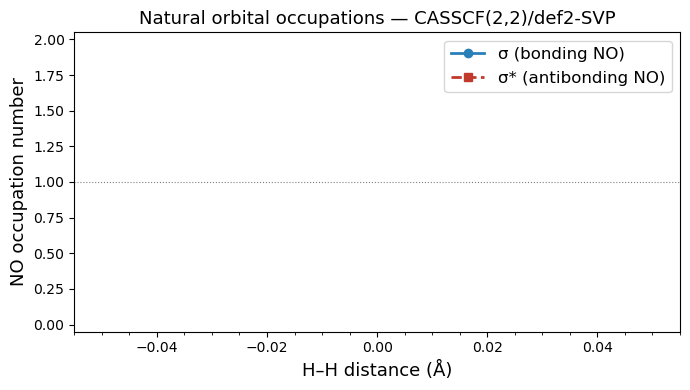

In [9]:
from opi.output.core import Output

def get_casscf_no_occupations(out_file):
    """Return sorted CASSCF natural orbital occupations via OPI property JSON."""
    prop_file = Path(str(out_file).replace('.out', '.property.json'))
    if not prop_file.exists():
        return []
    output = Output(basename=prop_file.stem.replace('.property', ''),
                    working_dir=prop_file.parent)
    output.parse()
    result = output.results
    # CAS natural orbital occupations are in cas_energy or nat_orbitals
    try:
        no = result.properties.nat_orbitals
        if no and no.occuno:
            occs = [x for row in no.occuno for x in row]
            return sorted(occs, reverse=True)
    except Exception:
        pass
    return []

no_bonding     = []
no_antibonding = []

for r in r_values:
    tag  = f"h2_{r:.2f}".replace('.', 'p')
    occs = get_casscf_no_occupations(JOBDIR / f"{tag}_casscf.out")
    no_bonding.append(occs[0]     if len(occs) > 0 else float('nan'))
    no_antibonding.append(occs[1] if len(occs) > 1 else float('nan'))

no_bonding     = np.array(no_bonding)
no_antibonding = np.array(no_antibonding)

print('Sample occupations at r=0.74 Å:', no_bonding[2], no_antibonding[2])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r_values, no_bonding,     'o-',  color='#2980b9', lw=2, label='σ (bonding NO)')
ax.plot(r_values, no_antibonding, 's--', color='#c0392b', lw=2, label='σ* (antibonding NO)')
ax.axhline(1.0, color='grey', lw=0.8, ls=':')
ax.set_xlabel('H–H distance (Å)', fontsize=13)
ax.set_ylabel('NO occupation number', fontsize=13)
ax.set_title('Natural orbital occupations — CASSCF(2,2)/def2-SVP', fontsize=13)
ax.set_ylim(-0.05, 2.05)
ax.legend(fontsize=12)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
plt.tight_layout()
plt.savefig('h2_no_occupations.pdf')
plt.show()

### ✏️ Fill in the table

Read the values from the plot and complete the table:

| r (Å) | σ occupation | σ* occupation | Character |
|--------|-------------|--------------|----------|
| 0.74 | _____ | _____ | single-reference / multireference? |
| 1.2 | _____ | _____ | |
| 2.0 | _____ | _____ | |
| 4.0 | _____ | _____ | |

**Q8.** At what H–H distance do the two occupation numbers become approximately equal (within 0.1 of each other)? Compare this to the UHF instability point from Q5.

*Your answer:*
```

```

**Q9.** You need to locate a transition state where the breaking bond has length ~1.8 Å. A colleague suggests B3LYP/def2-TZVP. Based on what you have seen here, what would you tell them?

*Your answer:*
```

```

---
## Part 5: A note on CCSD and the full CI limit

For H₂, CCSD is **exact** — it equals Full CI. With only 2 electrons, singles and doubles exhaust all possible excitations, so CCSD captures 100% of the correlation energy at every geometry, including dissociation.

If you added a CCSD curve to the plot, it would:
- Lie *below* CASSCF(2,2) near equilibrium (CASSCF misses dynamic correlation)
- Converge to the *same* correct dissociation limit

This is a special property of the two-electron system. For any larger molecule — like N₂, which we study next — CCSD is no longer exact, and the static correlation problem returns with dramatic consequences for the potential energy curve.

> **Technical note on this Mahti setup:** CCSD with 4 MPI ranks crashes for H₂/def2-SVP because `orca_mdci_mpi` requires a minimum number of basis functions per MPI rank. This is not a bug — H₂ with def2-SVP simply has too few basis functions (10) to distribute across 4 processes. N₂/def2-SVP works fine with 4 cores.

---
## Summary

Fill in the blanks:

1. At equilibrium, σ occupation ≈ **_____**, σ* occupation ≈ **_____**. The wavefunction is **single-reference / multireference** (circle one).

2. At dissociation, σ and σ* each have occupation ≈ **_____**. This is called **_____ correlation**.

3. RHF fails at dissociation because it forces both electrons into the **_____** orbital, giving each H atom **_____ electrons** on average instead of 1.

4. UHF dissociates correctly but produces ⟨S²⟩ ≈ **_____** — a 50/50 mixture of **_____** and **_____** states. This is **spin contamination**.

5. CASSCF(2,2) achieves correct dissociation *and* preserves spin symmetry by representing the wavefunction as a linear combination of |σσ̄⟩ and **_____**.

6. For H₂ specifically, CCSD = **_____** because with 2 electrons, singles and doubles exhaust the full CI expansion.

---

**➜ Continue to Notebook 2:** *N₂ — when the gold standard fails*